/tmp/ipykernel_158/402043628.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


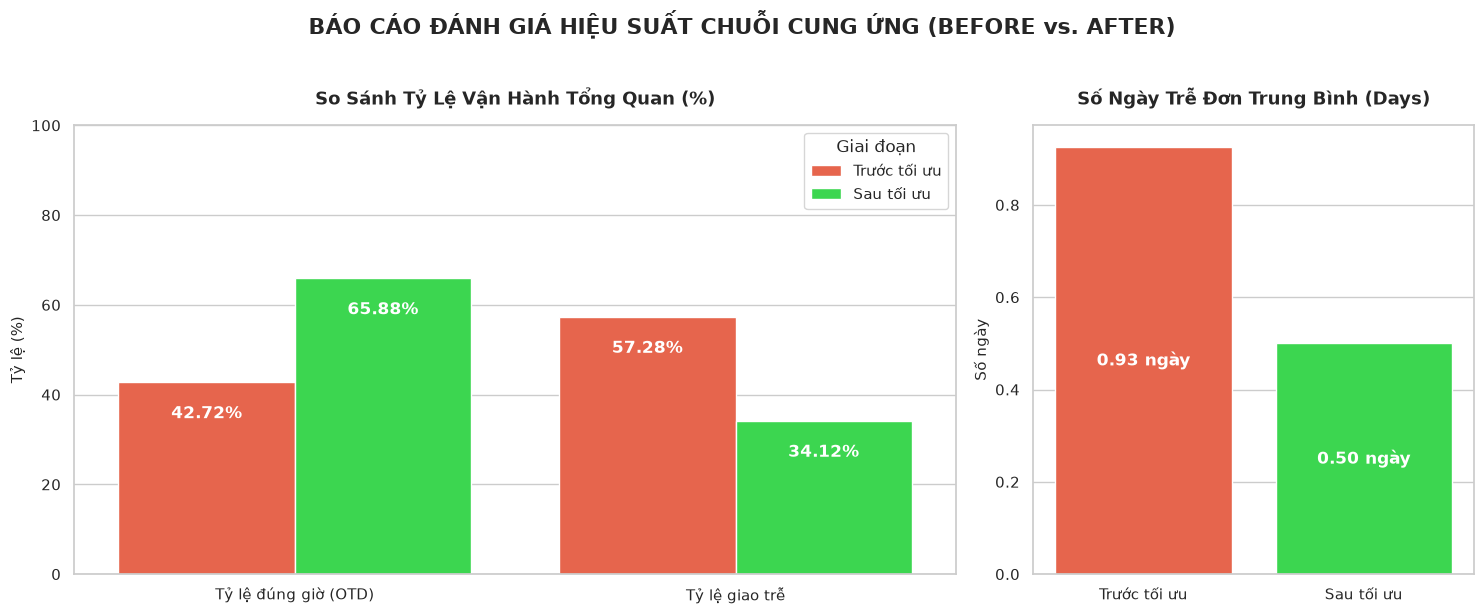

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. ĐỌC VÀ CHUẨN BỊ DỮ LIỆU
df_orig = pd.read_csv("data/processed/supply_chain_processed.csv")
df_opt = pd.read_csv("data/processed/optimized.csv")

# Tính toán các chỉ số cho tập dữ liệu Gốc (Before)
df_orig["Delay_Days"] = np.where(
    (val := (df_orig.actual_lead_time - df_orig.scheduled_lead_time)) < 0, 0, val
)
df_orig["is_late_calculated"] = np.where(
    (df_orig["scheduled_lead_time"] - df_orig["actual_lead_time"]) >= 0, 0, 1
)

before_otd = (1 - df_orig["is_late_calculated"].mean()) * 100
before_late = df_orig["is_late_calculated"].mean() * 100
before_delay = df_orig["Delay_Days"].mean()

# Tính toán các chỉ số cho tập dữ liệu Tối ưu (After)
after_otd = (1 - df_opt["is_late"].mean()) * 100
after_late = df_opt["is_late"].mean() * 100
after_delay = df_opt["Delay_Days"].mean()

# Tạo DataFrame phục vụ vẽ biểu đồ
df_kpi_rates = pd.DataFrame(
    {
        "Giai đoạn": ["Trước tối ưu", "Sau tối ưu", "Trước tối ưu", "Sau tối ưu"],
        "Chỉ số": [
            "Tỷ lệ đúng giờ (OTD)",
            "Tỷ lệ đúng giờ (OTD)",
            "Tỷ lệ giao trễ",
            "Tỷ lệ giao trễ",
        ],
        "Giá trị (%)": [before_otd, after_otd, before_late, after_late],
    }
)

df_kpi_days = pd.DataFrame(
    {
        "Giai đoạn": ["Trước tối ưu", "Sau tối ưu"],
        "Số ngày trễ TB": [before_delay, after_delay],
    }
)

# 2. THIẾT KẾ GIAO DIỆN BIỂU ĐỒ
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={"width_ratios": [2, 1]})

# --- SUBPLOT 1: SO SÁNH TỶ LỆ DỰA TRÊN % ---
sns.barplot(
    data=df_kpi_rates,
    x="Chỉ số",
    y="Giá trị (%)",
    hue="Giai đoạn",
    ax=axes[0],
    palette=["#ff5334", "#22f03d"],
)
axes[0].set_title(
    "So Sánh Tỷ Lệ Vận Hành Tổng Quan (%)", fontsize=13, weight="bold", pad=15
)
axes[0].set_ylabel("Tỷ lệ (%)", fontsize=11)
axes[0].set_xlabel("")
axes[0].set_ylim(0, 100)

# Thêm Data Labels hiển thị số liệu trực tiếp trên cột %
for p in axes[0].patches:
    if p.get_height() > 0:
        axes[0].annotate(
            f"{p.get_height():.2f}%",
            (p.get_x() + p.get_width() / 2.0, p.get_height() - 7),
            ha="center",
            va="center",
            color="white",
            weight="bold",
            xytext=(0, 0),
            textcoords="offset points",
        )

# --- SUBPLOT 2: SO SÁNH SỐ NGÀY TRỄ TRUNG BÌNH ---
sns.barplot(
    data=df_kpi_days,
    x="Giai đoạn",
    y="Số ngày trễ TB",
    ax=axes[1],
    palette=["#ff5334", "#22f03d"],
)
axes[1].set_title(
    "Số Ngày Trễ Đơn Trung Bình (Days)", fontsize=13, weight="bold", pad=15
)
axes[1].set_ylabel("Số ngày", fontsize=11)
axes[1].set_xlabel("")

# Thêm Data Labels cho cột số ngày
for p in axes[1].patches:
    axes[1].annotate(
        f"{p.get_height():.2f} ngày",
        (p.get_x() + p.get_width() / 2.0, p.get_height() / 2.0),
        ha="center",
        va="center",
        color="white",
        weight="bold",
        xytext=(0, 0),
        textcoords="offset points",
    )

plt.suptitle(
    "BÁO CÁO ĐÁNH GIÁ HIỆU SUẤT CHUỖI CUNG ỨNG (BEFORE vs. AFTER)",
    fontsize=16,
    weight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

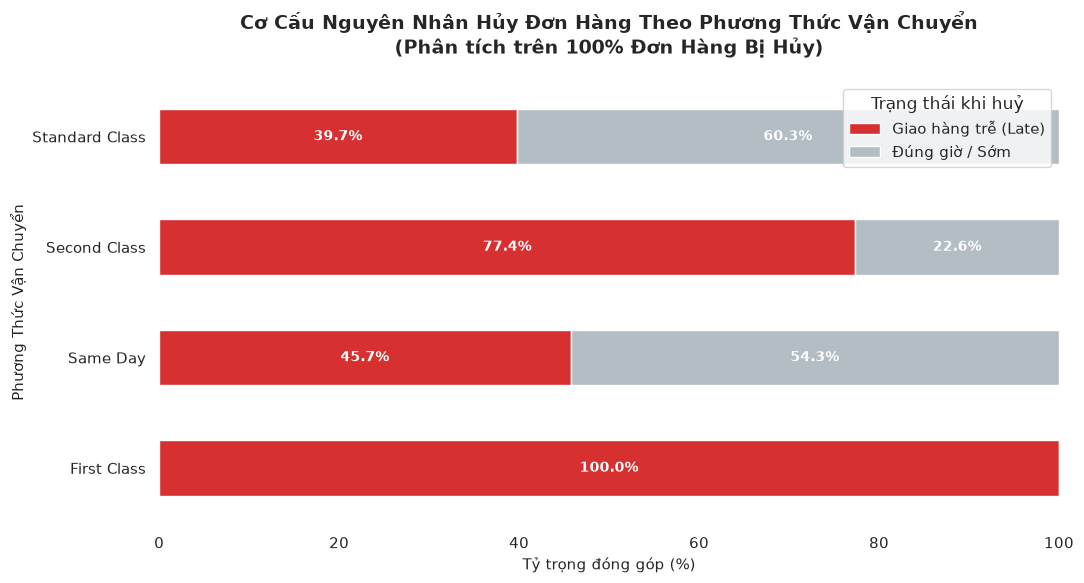

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. ĐỌC VÀ LỌC DỮ LIỆU ĐƠN HỦY
df_orig = pd.read_csv("data/processed/supply_chain_processed.csv")

# Lọc các đơn hàng bị hủy
df_cancelled = df_orig[df_orig["Delivery Status"] == "Shipping canceled"].copy()

# Xác định trạng thái trễ đơn tại thời điểm hủy
df_cancelled["Trạng thái đơn"] = np.where(
    (df_cancelled["scheduled_lead_time"] - df_cancelled["actual_lead_time"]) >= 0,
    "Đúng giờ / Sớm",
    "Giao hàng trễ (Late)",
)

# Tạo bảng chéo (Crosstab) tính tỷ lệ phần trăm 100% theo từng Phương thức vận chuyển
cancel_matrix = pd.crosstab(
    df_cancelled["Shipping Mode"],
    df_cancelled["Trạng thái đơn"],
    normalize="index",
) * 100

# Sắp xếp lại thứ tự cột để đưa lý do "Giao hàng trễ" ra trước làm điểm nhấn thị giác
cancel_matrix = cancel_matrix[["Giao hàng trễ (Late)", "Đúng giờ / Sớm"]]

# 2. THIẾT KẾ BIỂU ĐỒ CỘT CHỒNG 100% (NGANG)
sns.set_theme(style="white")
ax = cancel_matrix.plot(
    kind="barh", stacked=True, figsize=(11, 6), color=["#d63031", "#b2bec3"]
)

# Tinh chỉnh tiêu đề và nhãn
plt.title(
    "Cơ Cấu Nguyên Nhân Hủy Đơn Hàng Theo Phương Thức Vận Chuyển\n(Phân tích trên 100% Đơn Hàng Bị Hủy)",
    fontsize=14,
    weight="bold",
    pad=20,
)
plt.xlabel("Tỷ trọng đóng góp (%)", fontsize=11)
plt.ylabel("Phương Thức Vận Chuyển", fontsize=11)
plt.xlim(0, 100)

# Thêm Data Labels trực tiếp vào bên trong các phân đoạn chồng
for p in ax.patches:
    width = p.get_width()
    height = p.get_height()
    x, y = p.get_xy()
    if width > 0:  # Chỉ hiển thị nhãn nếu phân đoạn đó có giá trị
        ax.annotate(
            f"{width:.1f}%",
            (x + width / 2, y + height / 2),
            ha="center",
            va="center",
            color="white",
            weight="bold",
            fontsize=10,
        )

# Đặt vị trí chú thích (Legend) tinh tế ở góc phải dưới
plt.legend(
    title="Trạng thái khi huỷ", loc="best", frameon=True, facecolor="white"
)
sns.despine(left=True, bottom=True)  # Loại bỏ khung viền thừa để đồ họa thoáng hơn
plt.tight_layout()
plt.show()